In [1]:
from pathlib import Path  ### switching to pathlib path-handling instead of the os - should work consistently between HPC and local machine
import sys

# current working directory of the notebook / script
cwd = Path.cwd()

# assume "scripts" folder is one level up from cwd
project_root = cwd.parent.resolve()

if str(project_root) not in sys.path:
    print("Adding to sys.path:", project_root)
    sys.path.append(str(project_root)) # add root to Python path (as a string) for finding scripts modules further


Adding to sys.path: C:\Users\Lada\Desktop\job\tsn_rocks\Image-Analysis-Summer-Project


In [2]:
# 0. loading libraries (could be removed after all modules are loaded from the scripts)
import glob
import tifffile
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.color import label2rgb

from skimage.exposure import rescale_intensity
from skimage.transform import resize

from cellpose import models
from stardist.models import StarDist3D 

# loading scripts
from scripts.pre_processing import preprocess_3d_image ### pre-processing function (normalisation + optional downsampling)
from scripts.segment_3d import segment_with_stardist, save_segmentation_results ### StarDist3D (3d_demo) segmentation model - light and relatively quick to run




Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.10.18 
torch version:  	2.7.1+cpu! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




In [3]:
###### configuration ######

input_folder = project_root.parent.resolve() / "input_data" / "Images_BBBC050" / "test" / "Images" # put the directory to your input data, relative to the project folder
                                                                                                   # project_root.parent() derives directory above the project folder root
#input_folder = project_root.parent.resolve() / "input_data" / "BBBC035" / "BBBC035_v1_dataset" / "01" 

#input_folder = project_root.parent.resolve() / "input_data" / "2017_07_21_Tom20" / "AICS-11-part13" 


### 1. loading and pre-processing images


In [4]:
# 1) loading image: detect and preview

# detect all .tif files                                         # TODO: replace with the function
tif_files = sorted(input_folder.glob("*.tif"))
print(f"Detected {len(tif_files)} TIFF file(s) in: {input_folder}")

if not tif_files:
    raise FileNotFoundError("No .tif files found in the specified folder.")

### preview first one
img = tifffile.imread(tif_files[0])
print(f"Example image: {tif_files[0]}")
print(f"Image shape: {img.shape}")
print(f"Intensity range: [{img.min()} - {img.max()}]")

if img.ndim == 4:
    z, y, x, c = img.shape
    print(f"Multi-channel 3D image with {c} channels")
    selected_channel = 0  # TODO: replace with user input if needed?
    img_to_segment = img[..., selected_channel]
elif img.ndim == 3:
    z, y, x = img.shape
    print("Grayscale 3D image")
    selected_channel = None
    img_to_segment = img
else:
    raise ValueError("Unsupported image shape (must be 3D or 4D)")

Detected 44 TIFF file(s) in: C:\Users\Lada\Desktop\job\tsn_rocks\input_data\Images_BBBC050\test\Images
Example image: C:\Users\Lada\Desktop\job\tsn_rocks\input_data\Images_BBBC050\test\Images\Emb1_t001.tif
Image shape: (51, 114, 112)
Intensity range: [1730 - 11338]
Grayscale 3D image


In [ ]:
### example - dealing with unconventional dimention order: reoder the array according

# reading the files
img = tifffile.imread(tif_files[0])  # shape (60, 9, 624, 924) = (Z, C, Y, X)

# reorder axes: current (Z, C, Y, X) → desired (Z, Y, X, C)
img_fixed = np.moveaxis(img, 1, -1)  # moves second axis (C, 1) to the last position (-1)

print("Fixed shape:", img_fixed.shape)  # (60, 624, 924, 9)

#channel 0: cell membrane
#channel 1: Tomm20
#channel 2: nucleus


In [6]:
# 2) pre-preprocessing (current: norm + optional downsampling)

### params ###
downsize_factor = 0.75    # (Y, X) or None to keep original            TODO: make sure that downsampling is proportionate? (e.g. if the original size is not 1:1)
per_slice_norm = False        # True = normalize per-slice, False = normalize whole stack
selected_channel = 2          # select channel to be processed for segmentation

### load and pre-process all images in the folder           
frames = []

for f in tif_files:
    
    volume = tifffile.imread(f)

    # --- step 1: fix dimension order if needed ---
    if volume.ndim == 4:
        # find the axis that looks like "channel" (size < 10) -- example of how channels axis could be identified (but could be T or S as well)
        channel_axis = np.argmin(volume.shape)  
        if volume.shape[channel_axis] < 10 and channel_axis != volume.ndim - 1:
            # move that axis to the last position
            volume = np.moveaxis(volume, channel_axis, -1) # reorder axes: current (Z, C, Y, X) → desired (Z, Y, X, C)

    # --- step 2: if multi-channel, select one channel ---
    if volume.ndim == 4 and selected_channel is not None:
        volume = volume[..., selected_channel]

    # --- step 3: apply preprocessing ---
    processed = preprocess_3d_image(
        volume,
        downsize_factor=downsize_factor,
        per_slice=per_slice_norm
    )
    frames.append(processed)

print(f"Processed {len(frames)} volume(s)")
print(f"Final shape per volume: {frames[0].shape}")
print(f"Value range after normalization: [{frames[0].min():.3f} - {frames[0].max():.3f}]")

Processed 44 volume(s)
Final shape per volume: (51, 86, 84)
Value range after normalization: [0.003 - 0.947]


### 2. segmentation of nuclei


Running StarDist...
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Segmented volume 0 with shape (51, 86, 84)


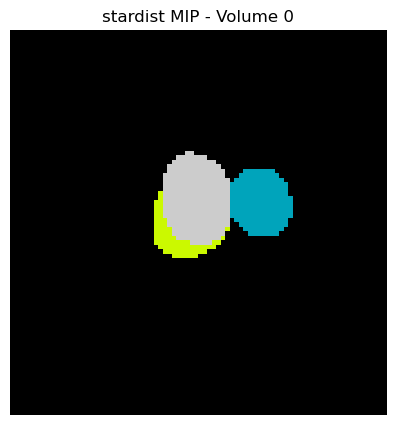

Running StarDist...
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Segmented volume 1 with shape (51, 86, 84)


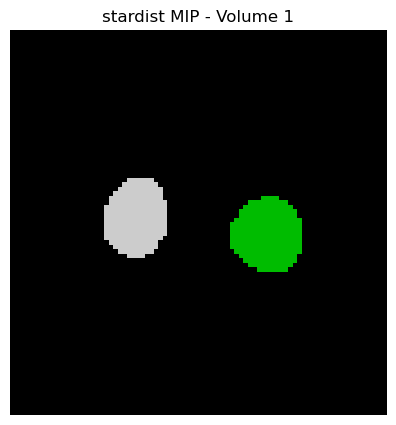

Running StarDist...
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Segmented volume 2 with shape (51, 86, 84)


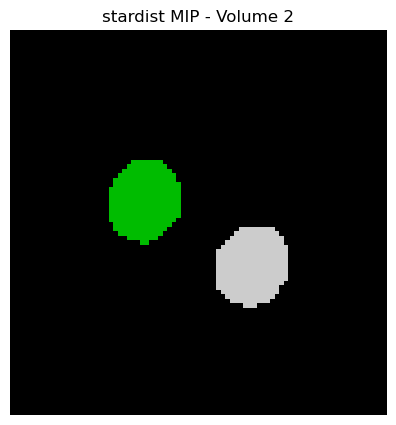

Running StarDist...
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Segmented volume 3 with shape (51, 86, 84)


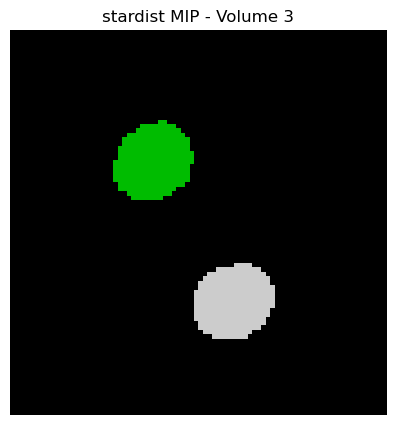

Running StarDist...
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Segmented volume 4 with shape (51, 86, 84)


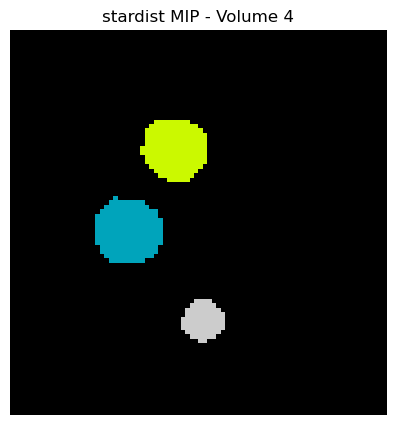

Running StarDist...
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Segmented volume 5 with shape (51, 86, 84)


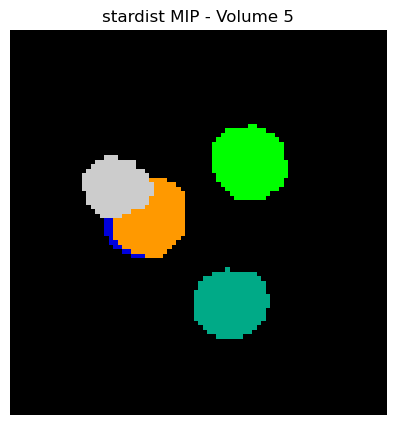

Running StarDist...
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Segmented volume 6 with shape (51, 86, 84)


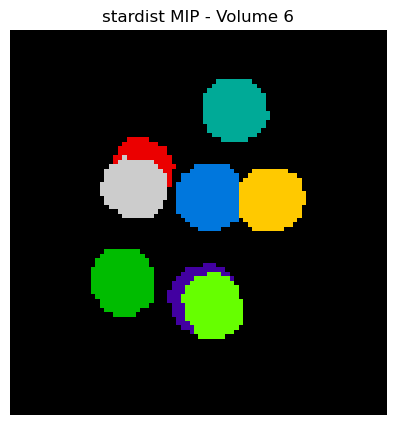

Running StarDist...
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Segmented volume 7 with shape (51, 86, 84)


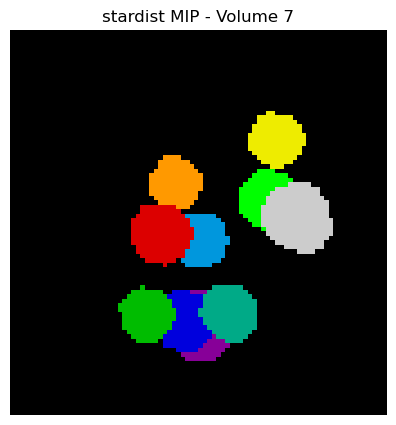

Running StarDist...
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Segmented volume 8 with shape (51, 86, 84)


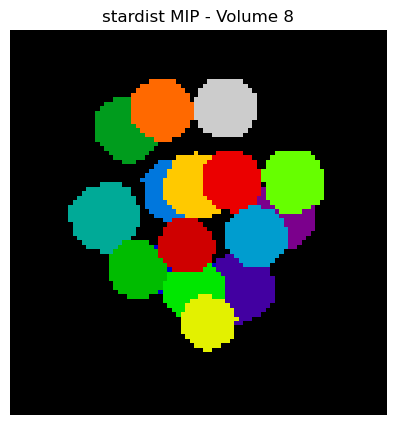

Running StarDist...
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Segmented volume 9 with shape (51, 86, 84)


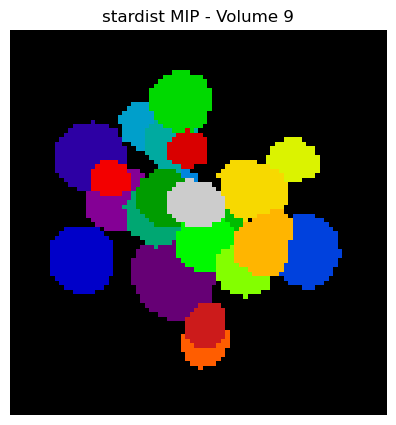

In [7]:
### example use with test images

### params ###
num_test_volumes = 10  # number of volumes from `frames` to segment
normalize_input = True # for Stardist
use_model = "stardist"  # "cellpose" or "stardist"
diameter = None        # or specify an estimate, e.g., 20
channels = [0, 0]      # grayscale input for Cellpose


### doing segmentation for each 3d image ("volume_norm") 
for i in range(min(num_test_volumes, len(frames))):
    volume_norm = frames[i]  # (Z, Y, X)

    # run segmentation
    if use_model == "cellpose":
        seg_mask = segment_with_cellpose(volume_norm, diameter=diameter, channels=channels)  ### too heavy to try to run locally
    elif use_model == "stardist":
        nuclei_seg_mask = segment_with_stardist(volume_norm)
    else:
        raise ValueError("Unknown model selected")

    print(f"Segmented volume {i} with shape {nuclei_seg_mask.shape}") ### CellPose and StarDist should return labelled mask already

    # visualize MIP of segmentation - 
    mip = nuclei_seg_mask.max(axis=0)
    plt.figure(figsize=(5, 5))
    plt.imshow(mip, cmap='nipy_spectral')
    plt.title(f"{use_model} MIP - Volume {i}")
    plt.axis('off')
    plt.show()
    plt.close()



In [ ]:
### example use with test images (pre-processing included to preserve file name for saving outputs)

### configs ###
OUTPUT_DIR = project_root.parent / "output_data" / "Images_BBBC050" / "test" / "Images"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### params ###
num_test_volumes = 10  # number of volumes from `frames` to segment
use_model = "stardist"  # "cellpose" or "stardist"
diameter = None        # or specify an estimate, e.g., 20
channels = [0, 0]      # grayscale input for Cellpose

### pre-processing params ###
downsize_factor = 0.5    # (Y, X) or None to keep original                                 TODO: make sure that downsampling is proportionate? (e.g. if the original size is not 1:1)
per_slice_norm = False        # True = normalize per-slice, False = normalize whole stack


# pair each frame with its path to keep track of original names
frame_paths = sorted(input_folder.glob("*.tif"))

for i in range(min(num_test_volumes, len(frame_paths))):
    frame_path = frame_paths[i]
    frame_name = frame_path.stem  # preserve original name
    
    # load & normalize if needed
    volume = tifffile.imread(frame_path)
    volume_norm = preprocess_3d_image(volume, downsize_factor=downsize_factor, per_slice=per_slice_norm)

    # run segmentation
    if use_model == "cellpose":
        nuclei_seg_mask = segment_with_cellpose(volume_norm, diameter=diameter, channels=channels)
    elif use_model == "stardist":
        nuclei_seg_mask = segment_with_stardist(volume_norm)
    else:
        raise ValueError("Unknown model selected")

    print(f"Segmented {frame_name} with shape {nuclei_seg_mask.shape}")

    # # optional: show MIP
    # mip = nuclei_seg_mask.max(axis=0)
    # plt.figure(figsize=(5, 5))
    # plt.imshow(mip, cmap='nipy_spectral')
    # plt.title(f"{use_model} MIP - {frame_name}")
    # plt.axis('off')
    # plt.show()
    # plt.close()

    # save results immediately
    save_segmentation_results(
        volume_norm,  # original image (normalized or raw)
        nuclei_seg_mask,
        output_root=OUTPUT_DIR,
        experiment_label=frame_name,
        save_overlay=True
    )

In [ ]:
# (optional): visualise the example segmentation result using Napari (have not checked on myriad)

%gui qt
import napari

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(volume_norm, name='Raw Image', rendering='mip', colormap='gray') ### adding the original 3d grey-scale image
viewer.add_labels(nuclei_seg_mask, name='Segmentation Mask') ### adding a created mask overlay

In [ ]:
# 2.2 : nuclei quantification

In [8]:
# extracting voxel size from the .ome-tif file
import tifffile
from ome_types import from_xml

def get_voxel_size(path):
    """
    Extract voxel size from an OME-TIFF file.   TODO: add support for just tiff files
    Returns (Z, Y, X) in micrometers if available, otherwise None.
    """
    with tifffile.TiffFile(path) as tif:
        if tif.ome_metadata:  # OME-XML present
            omexml = from_xml(tif.ome_metadata)
            pixels = omexml.images[0].pixels
            return (
                pixels.physical_size_z,
                pixels.physical_size_y,
                pixels.physical_size_x,
            )
        else:
            return None  # fallback → ask user to input manually

#path = r"C:\Users\Lada\Desktop\job\tsn_rocks\input_data\2017_07_21_Tom20\AICS-11-part13\AICS-11_1301.ome.tif"
#path = r"C:\Users\Lada\Desktop\job\tsn_rocks\input_data\BBBC035\BBBC035_v1_dataset\01\t000.tif"
path = r"C:\Users\Lada\Desktop\job\tsn_rocks\input_data\Images_BBBC050\test\Images\Emb1_t001.tif"
voxel_size = get_voxel_size(path)
print("Voxel size (µm):", voxel_size)


Voxel size (µm): None


In [9]:
from skimage.measure import regionprops, label

def quantify_volumes(mask, voxel_size=None):
    """
    Quantify object volumes from a labeled segmentation mask.

    Parameters
    ----------
    mask : ndarray
        Labeled segmentation mask (3D). 0 = background, 1...N = objects.
    voxel_size : tuple or None
        (z_size, y_size, x_size) in micrometers.
        If None, volumes are returned in voxel counts.

    Returns
    -------
    volumes : dict
        {label_id: volume, ...} where volume is in µm³ if voxel_size is given,
        otherwise in voxel units.
    unit : str
        "µm³" if voxel_size provided, else "voxels"
    """
    if voxel_size is not None:
        z_um, y_um, x_um = voxel_size
        voxel_volume = z_um * y_um * x_um
    else:
        voxel_volume = 1  # each voxel counts as 1 unit

    props = regionprops(mask)
    volumes = {prop.label: prop.area * voxel_volume for prop in props}

    return volumes, ("µm³" if voxel_size is not None else "voxels")


In [ ]:
#### extra functions:
from skimage.morphology import ball, binary_closing

def tidy_mask(mask_zyx, min_voxels=50, hole_area_max=64, closing_radius=1):
    # ensure binary for morphology
    binary = mask_zyx > 0
    if closing_radius > 0:
        selem = ball(closing_radius)
        binary = binary_closing(binary, selem)
    binary = remove_small_holes(binary, area_threshold=hole_area_max)
    binary = remove_small_objects(binary, min_size=min_voxels)
    # relabel to instances
    return label(binary)

def sphere_volume_um3(d_um):
    r = d_um / 2.0
    return (4.0/3.0) * np.pi * (r**3)

In [10]:
quantify_volumes(nuclei_seg_mask, voxel_size)

({1: 1721.0,
  2: 1001.0,
  3: 1191.0,
  4: 1045.0,
  5: 1161.0,
  6: 868.0,
  7: 577.0,
  8: 620.0,
  9: 679.0,
  10: 646.0,
  11: 526.0,
  12: 794.0,
  13: 728.0,
  14: 494.0,
  15: 429.0,
  16: 909.0,
  17: 710.0,
  18: 391.0,
  19: 200.0,
  20: 259.0,
  21: 242.0,
  22: 582.0},
 'voxels')